Total TTree entries: 100000

Valid Compton gamma records:
Volume 2: 0
Volume 3: 15980
Volume 6: 6

First 10 rows:
   event_number  record_index  volume  pdg   pro  E0_keV  Eprime_k_keV  \
0             9             3       3   22  2013   662.0    269.253878   
1             9             4       3   22  2013   662.0    266.965229   
2            11             3       3   22  2013   662.0    417.724361   
3            17             3       3   22  2013   662.0    413.538403   
4            22             3       3   22  2013   662.0    224.689024   
5            53             3       3   22  2013   662.0    659.315602   
6            64             3       3   22  2013   662.0    348.702174   
7            77             3       3   22  2013   662.0    656.264320   
8            82             3       3   22  2013   662.0    560.996324   
9            90             3       3   22  2013   662.0    560.730908   

       Et_keV   theta_deg  q_gamma_keV_c     Q_keV_c  Q_signed_au  \
0 

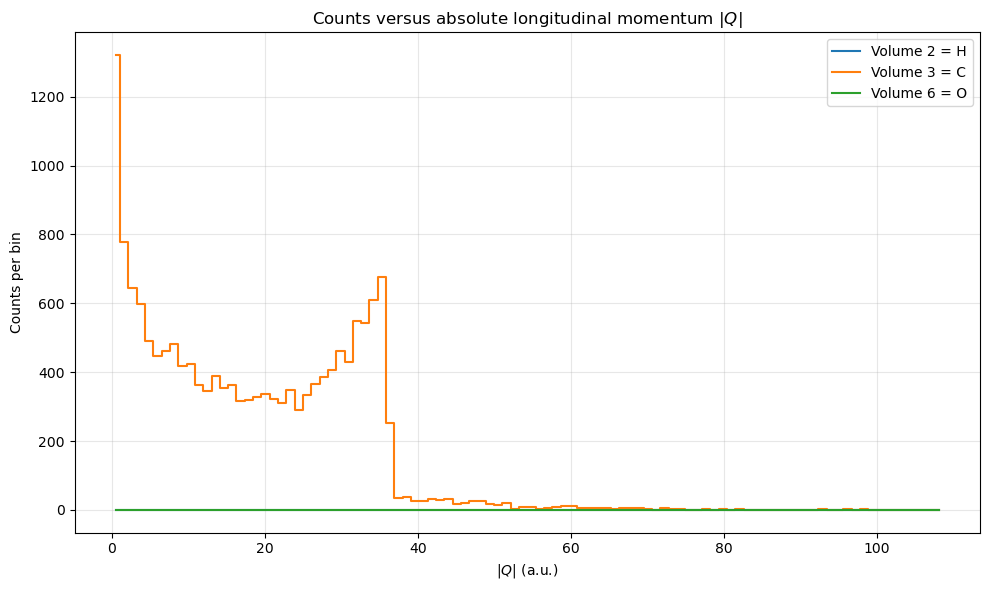

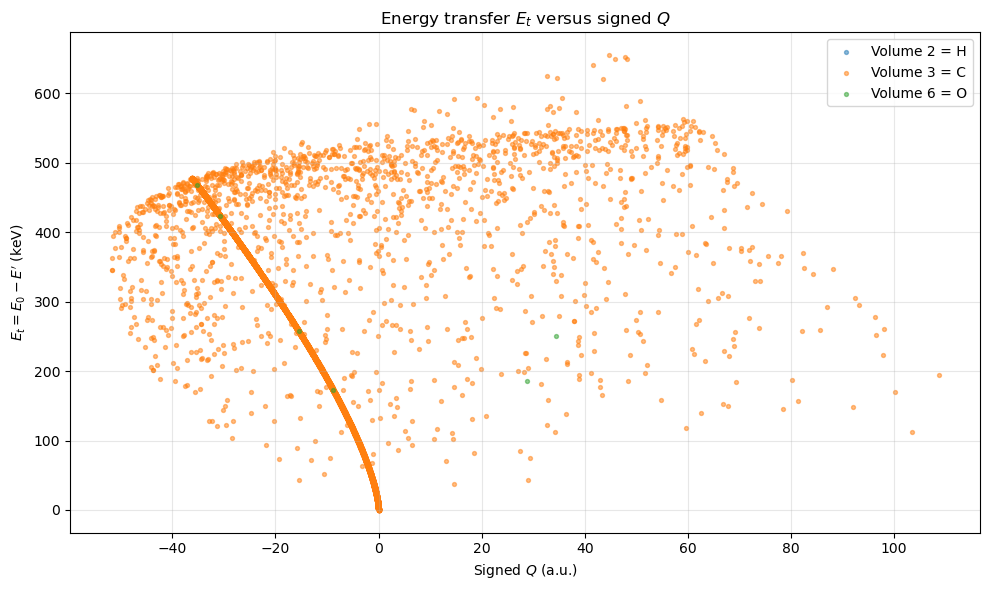

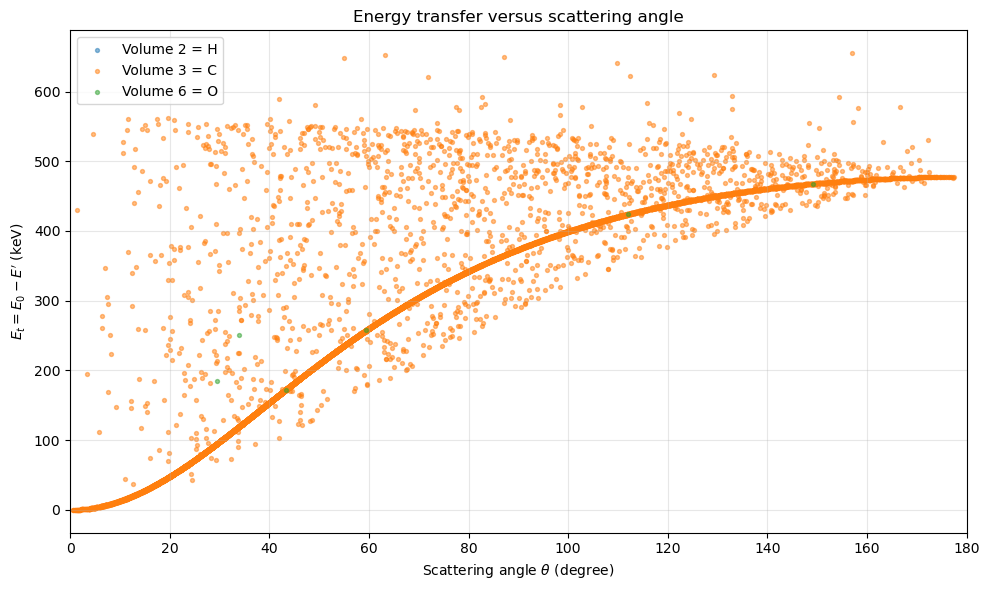

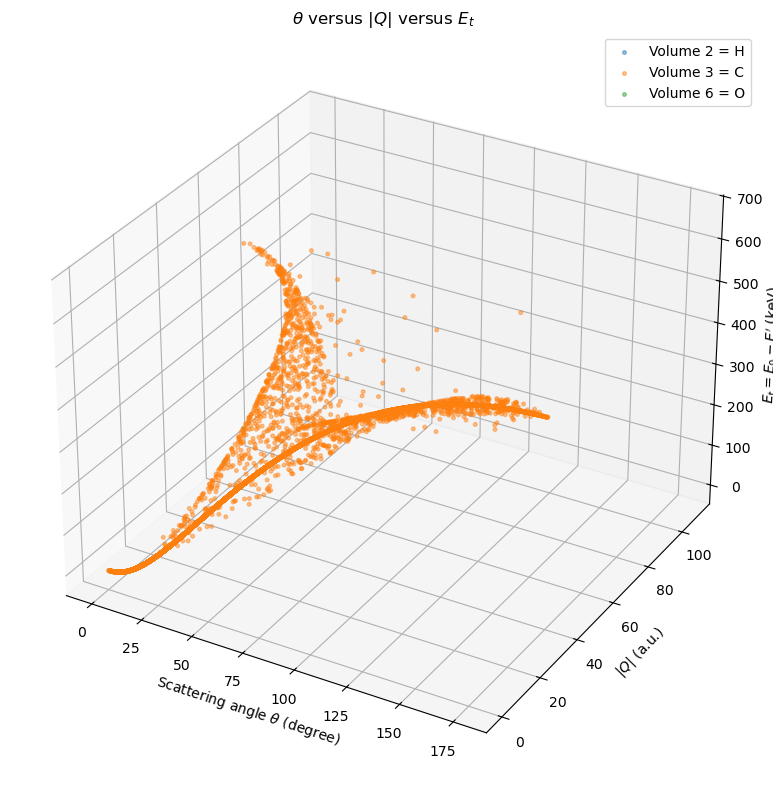


Saved |Q| versus counts CSV:
/root/geant4/detector/Lung_Elements/HCO_absQ_vs_counts.csv


In [2]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# =====================================================
# USER SETTINGS
# =====================================================

file_path = "/root/geant4/detector/Lung_Elements/HCO.root"
tree_name = "t"

E0 = 662.0          # incident gamma energy, keV
ME = 511.0          # electron rest energy, keV
P_AU = 3.72738      # 1 a.u. momentum = 3.72738 keV/c

selected_volumes = [2, 3, 6]

compton_process = 2013
gamma_pdg = 22

# Incident gamma direction: along -y
incident_direction = np.array([0.0, -1.0, 0.0], dtype=float)
incident_direction /= np.linalg.norm(incident_direction)

csv_file = "HCO_Compton_Q_Et_theta.csv"

# Number of bins for |Q| histogram
number_of_Q_bins = 100

# =====================================================
# OPEN ROOT FILE
# =====================================================

if not os.path.exists(file_path):
    raise FileNotFoundError(file_path)

root_file = ROOT.TFile.Open(file_path)

if not root_file or root_file.IsZombie():
    raise RuntimeError("Could not open ROOT file.")

tree = root_file.Get(tree_name)

if tree is None:
    root_file.Close()
    raise RuntimeError(f"TTree '{tree_name}' was not found.")

print("Total TTree entries:", tree.GetEntries())

# =====================================================
# STORAGE
# =====================================================

rows = []

# IMPORTANT:
# include all selected volumes
counts = {volume: 0 for volume in selected_volumes}

# =====================================================
# LOOP OVER TTREE
# =====================================================

for event_number, event in enumerate(tree):

    n_records = min(
        len(event.pdg),
        len(event.pro),
        len(event.vlm),
        len(event.k),
        len(event.px),
        len(event.py),
        len(event.pz)
    )

    for i in range(n_records):

        pdg = int(event.pdg[i])
        process = int(event.pro[i])
        volume = int(event.vlm[i])

        # ---------------------------------------------
        # Selection
        # ---------------------------------------------

        if volume not in selected_volumes:
            continue

        if pdg != gamma_pdg:
            continue

        if process != compton_process:
            continue

        # ---------------------------------------------
        # Scattered photon energy E'
        # ---------------------------------------------

        Eprime = float(event.k[i])

        if (
            not np.isfinite(Eprime)
            or Eprime <= 0.0
            or Eprime > E0
        ):
            continue

        # Energy transfer
        Et = E0 - Eprime

        # ---------------------------------------------
        # Outgoing gamma momentum
        # ---------------------------------------------

        px = float(event.px[i])
        py = float(event.py[i])
        pz = float(event.pz[i])

        momentum = np.array(
            [px, py, pz],
            dtype=float
        )

        momentum_magnitude = np.linalg.norm(momentum)

        if (
            not np.isfinite(momentum_magnitude)
            or momentum_magnitude <= 0.0
        ):
            continue

        outgoing_direction = momentum / momentum_magnitude

        # ---------------------------------------------
        # Actual scattering angle
        # ---------------------------------------------

        cos_theta = float(
            np.dot(
                incident_direction,
                outgoing_direction
            )
        )

        cos_theta = np.clip(
            cos_theta,
            -1.0,
            1.0
        )

        theta_rad = np.arccos(cos_theta)
        theta_deg = np.degrees(theta_rad)

        # ---------------------------------------------
        # Photon momentum transfer q
        # ---------------------------------------------

        q_squared = (
            E0**2
            + Eprime**2
            - 2.0 * E0 * Eprime * cos_theta
        )

        if (
            not np.isfinite(q_squared)
            or q_squared <= 0.0
        ):
            continue

        q_c = np.sqrt(q_squared)

        # q_c is in keV/c
        # because E0 and Eprime are in keV
        # and c = 1 is being used.

        # ---------------------------------------------
        # Longitudinal electron momentum Q
        # ---------------------------------------------

        Q_keV_c = (
            ME / q_c
        ) * (
            Et
            - q_c**2 / (2.0 * ME)
        )

        Q_au = Q_keV_c / P_AU

        if not np.isfinite(Q_au):
            continue

        # ---------------------------------------------
        # Save
        # ---------------------------------------------

        rows.append({
            "event_number": event_number,
            "record_index": i,
            "volume": volume,
            "pdg": pdg,
            "pro": process,

            "E0_keV": E0,
            "Eprime_k_keV": Eprime,
            "Et_keV": Et,

            "theta_deg": theta_deg,

            "q_gamma_keV_c": q_c,

            "Q_keV_c": Q_keV_c,
            "Q_signed_au": Q_au,
            "Q_absolute_au": abs(Q_au)
        })

        counts[volume] += 1


root_file.Close()

# =====================================================
# CREATE DATAFRAME
# =====================================================

results = pd.DataFrame(rows)

if results.empty:
    raise RuntimeError(
        "No valid Compton gamma records found "
        "for volumes 2, 3, and 6."
    )

results.to_csv(csv_file, index=False)

print("\nValid Compton gamma records:")

for volume in selected_volumes:
    print(f"Volume {volume}: {counts[volume]}")

print("\nFirst 10 rows:")
print(results.head(10))

print("\nSaved CSV:")
print(os.path.abspath(csv_file))

# =====================================================
# SEPARATE VOLUMES
# =====================================================

v2 = results[results["volume"] == 2].copy()
v3 = results[results["volume"] == 3].copy()
v6 = results[results["volume"] == 6].copy()

volume_data = {
    2: v2,
    3: v3,
    6: v6
}

volume_labels = {
    2: "Volume 2 = H",
    3: "Volume 3 = C",
    6: "Volume 6 = O"
}

# =====================================================
# PLOT 1
# |Q| vs COUNTS
# =====================================================

Q_all = results["Q_absolute_au"].to_numpy()

Q_min = 0.0
Q_max = np.nanmax(Q_all)

Q_bin_edges = np.linspace(
    Q_min,
    Q_max,
    number_of_Q_bins + 1
)

Q_bin_centers = 0.5 * (
    Q_bin_edges[:-1]
    + Q_bin_edges[1:]
)

plt.figure(figsize=(10, 6))

for volume in selected_volumes:

    df = volume_data[volume]

    hist_counts, _ = np.histogram(
        df["Q_absolute_au"],
        bins=Q_bin_edges
    )

    plt.step(
        Q_bin_centers,
        hist_counts,
        where="mid",
        linewidth=1.5,
        label=volume_labels[volume]
    )

plt.xlabel(r"$|Q|$ (a.u.)")
plt.ylabel("Counts per bin")
plt.title(
    r"Counts versus absolute longitudinal momentum $|Q|$"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# PLOT 2
# SIGNED Q vs Et
# =====================================================

plt.figure(figsize=(10, 6))

for volume in selected_volumes:

    df = volume_data[volume]

    plt.scatter(
        df["Q_signed_au"],
        df["Et_keV"],
        s=8,
        alpha=0.5,
        label=volume_labels[volume]
    )

plt.xlabel(r"Signed $Q$ (a.u.)")
plt.ylabel(r"$E_t = E_0-E'$ (keV)")
plt.title(
    r"Energy transfer $E_t$ versus signed $Q$"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# PLOT 3
# SCATTERING ANGLE theta vs Et
# =====================================================

plt.figure(figsize=(10, 6))

for volume in selected_volumes:

    df = volume_data[volume]

    plt.scatter(
        df["theta_deg"],
        df["Et_keV"],
        s=8,
        alpha=0.5,
        label=volume_labels[volume]
    )

plt.xlabel(r"Scattering angle $\theta$ (degree)")
plt.ylabel(r"$E_t = E_0-E'$ (keV)")
plt.title(
    r"Energy transfer versus scattering angle"
)
plt.xlim(0, 180)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# PLOT 4
# 3D: theta vs |Q| vs Et
# =====================================================

fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(
    111,
    projection="3d"
)

for volume in selected_volumes:

    df = volume_data[volume]

    ax.scatter(
        df["theta_deg"],
        df["Q_absolute_au"],
        df["Et_keV"],
        s=7,
        alpha=0.45,
        label=volume_labels[volume]
    )

ax.set_xlabel(
    r"Scattering angle $\theta$ (degree)"
)

ax.set_ylabel(
    r"$|Q|$ (a.u.)"
)

ax.set_zlabel(
    r"$E_t = E_0-E'$ (keV)"
)

ax.set_title(
    r"$\theta$ versus $|Q|$ versus $E_t$"
)

ax.legend()

plt.tight_layout()
plt.show()

# =====================================================
# OPTIONAL:
# SAVE HISTOGRAM COUNTS TO CSV
# =====================================================

counts_rows = []

for volume in selected_volumes:

    df = volume_data[volume]

    hist_counts, _ = np.histogram(
        df["Q_absolute_au"],
        bins=Q_bin_edges
    )

    for Q_center, count in zip(
        Q_bin_centers,
        hist_counts
    ):

        counts_rows.append({
            "volume": volume,
            "Q_absolute_au": Q_center,
            "counts": count
        })

counts_df = pd.DataFrame(counts_rows)

counts_csv_file = "HCO_absQ_vs_counts.csv"

counts_df.to_csv(
    counts_csv_file,
    index=False
)

print("\nSaved |Q| versus counts CSV:")
print(os.path.abspath(counts_csv_file))

Signed Q range:
Q_min = -51.79230569136481 a.u.
Q_max = 108.63610056038354 a.u.
Volume 2: no valid events


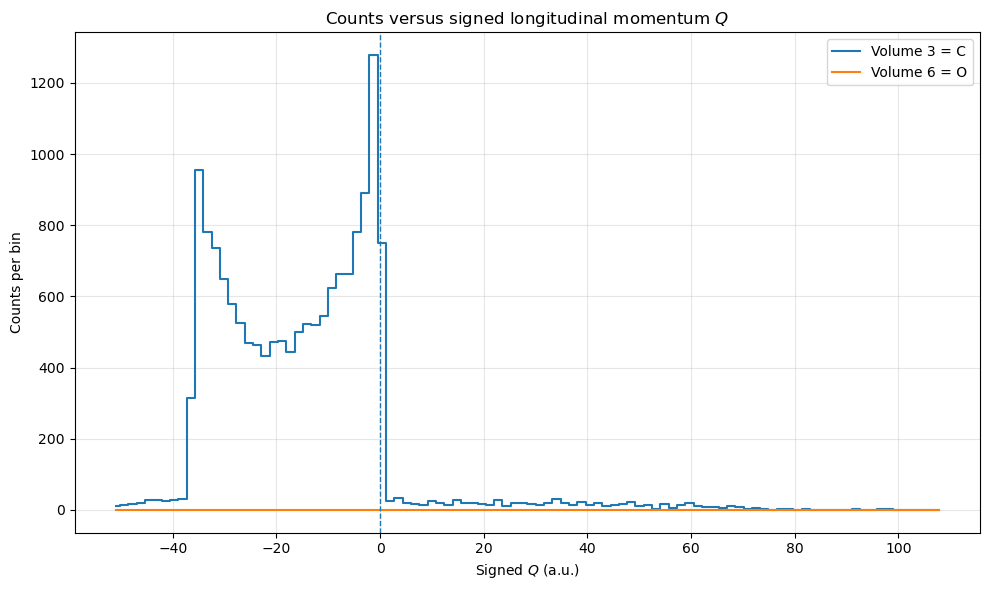

In [15]:
# =====================================================
# PLOT: COUNTS vs SIGNED Q
# Volumes 2, 3, and 6
# =====================================================

number_of_Q_bins = 100

# Use the complete signed-Q range
Q_all = results["Q_signed_au"].to_numpy()

Q_min = np.nanmin(Q_all)
Q_max = np.nanmax(Q_all)

print("Signed Q range:")
print("Q_min =", Q_min, "a.u.")
print("Q_max =", Q_max, "a.u.")

# Common bin edges for all three volumes
Q_bin_edges = np.linspace(
    Q_min,
    Q_max,
    number_of_Q_bins + 1
)

Q_bin_centers = 0.5 * (
    Q_bin_edges[:-1] +
    Q_bin_edges[1:]
)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10, 6))

for volume in [2, 3, 6]:

    df = volume_data[volume]

    if df.empty:
        print(f"Volume {volume}: no valid events")
        continue

    # Histogram of SIGNED Q
    hist_counts, _ = np.histogram(
        df["Q_signed_au"],
        bins=Q_bin_edges
    )

    plt.step(
        Q_bin_centers,
        hist_counts,
        where="mid",
        linewidth=1.5,
        label=volume_labels[volume]
    )

# Q = 0 reference
plt.axvline(
    0,
    linewidth=1,
    linestyle="--"
)

plt.xlabel(r"Signed $Q$ (a.u.)")
plt.ylabel("Counts per bin")

plt.title(
    r"Counts versus signed longitudinal momentum $Q$"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()